> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 16. Support Vector Machines

*Scope:* Classification as a geometry problem: find the widest possible separating band, and bend the space when no straight band exists.

Logistic regression finds *a* separating line by maximizing a likelihood. Support vector machines ask a
sharper question: **of all the lines that separate the classes, which one is furthest from both?**

That reframing turns classification into a geometry problem, and the geometry brings two things nothing
else in this material has — a solution that depends on only a handful of training points, and a way to fit
curved boundaries without ever constructing the curved features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.svm import SVC, LinearSVC, SVR, LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.inspection import DecisionBoundaryDisplay

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80        # this chapter is figure-heavy; keep the notebook small

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 16.1 The Maximum Margin Idea

When two classes are linearly separable there are **infinitely many** separating hyperplanes. Logistic
regression picks one by maximizing likelihood; a perceptron picks whichever one it stumbles into first.
Neither asks whether the chosen line is a *good* one.

In [2]:
from sklearn.linear_model import LogisticRegression, Perceptron

# Two clearly separated blobs.
X_sep = np.array([[1.0, 2.0], [1.5, 1.8], [2.0, 2.5], [1.2, 2.8], [2.2, 1.9],
                  [4.0, 4.5], [4.5, 4.0], [5.0, 4.8], [4.2, 5.2], [5.1, 4.2]])
y_sep = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])


def boundary_line(model, xs):
    """Return the y values of the decision boundary w0*x + w1*y + b = 0."""
    w = model.coef_[0]
    b = model.intercept_[0] if np.ndim(model.intercept_) else model.intercept_
    return -(w[0] * xs + b) / w[1]


xs = np.linspace(0.5, 5.5, 50)
models = {
    "logistic": LogisticRegression().fit(X_sep, y_sep),
    "perceptron": Perceptron(random_state=RANDOM_STATE).fit(X_sep, y_sep),
    "SVM (max margin)": SVC(kernel="linear", C=1000).fit(X_sep, y_sep),
}
for name, m in models.items():
    print(f"{name:<18} all training points correct: {m.score(X_sep, y_sep) == 1.0}")

logistic           all training points correct: True
perceptron         all training points correct: True
SVM (max margin)   all training points correct: True


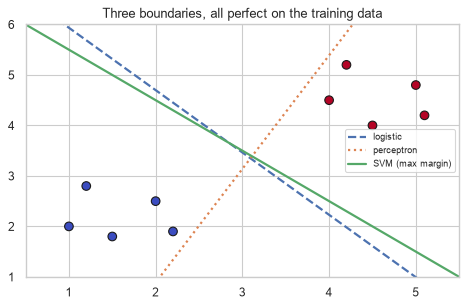

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap="coolwarm", s=60, edgecolor="k", zorder=3)
for (name, m), style in zip(models.items(), ("--", ":", "-")):
    ax.plot(xs, boundary_line(m, xs), style, lw=2, label=name)
ax.set_xlim(0.5, 5.5); ax.set_ylim(1.0, 6.0)
ax.set_title("Three boundaries, all perfect on the training data")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

All three are perfect on the training set, and they are not equally good. A boundary that skims one class
will misclassify the first new point that lands slightly to one side. The **margin** — the distance from
the boundary to the nearest training point of either class — is the natural measure of that robustness,
and the SVM maximizes it.

| Term | Is |
|---|---|
| **Margin** | The perpendicular distance from the boundary to the closest point of either class |
| **Support vectors** | The points that sit exactly on the margin (or violate it) |
| **Maximum-margin hyperplane** | The unique boundary that makes the margin as wide as possible |

The defining property is that **only the support vectors matter.** Delete every other training point and
the solution is unchanged.

In [4]:
svm = SVC(kernel="linear", C=1000).fit(X_sep, y_sep)

print(f"training points : {len(X_sep)}")
print(f"support vectors : {len(svm.support_)}   at indices {svm.support_}")
print(f"\nthe support vectors themselves:\n{svm.support_vectors_}")

training points : 10
support vectors : 3   at indices [2 5 6]

the support vectors themselves:
[[2.  2.5]
 [4.  4.5]
 [4.5 4. ]]


In [5]:
# Refit using ONLY the support vectors.
sv_only = SVC(kernel="linear", C=1000).fit(svm.support_vectors_, y_sep[svm.support_])

print("coefficients from all 10 points   :", svm.coef_[0])
print("coefficients from 3 support vectors:", sv_only.coef_[0])
print("\nidentical:", np.allclose(svm.coef_, sv_only.coef_) and
      np.allclose(svm.intercept_, sv_only.intercept_))

coefficients from all 10 points   : [0.5 0.5]
coefficients from 3 support vectors: [0.5 0.5]

identical: True


Seventy percent of the training data was discarded and the model did not change at all. No other algorithm
in this material has that property — a linear regression coefficient depends on every row, and a tree's
splits depend on the whole distribution.

### 16.2 The Hard-Margin Problem

Write the boundary as $\mathbf{w}\cdot\mathbf{x} + b = 0$, and encode the labels as $y \in \{-1, +1\}$
rather than $\{0, 1\}$ — this is the convention that makes the algebra work.

The (signed) distance from a point to the hyperplane is $\frac{\mathbf{w}\cdot\mathbf{x} + b}{\lVert \mathbf{w} \rVert}$.
Because $\mathbf{w}$ and $b$ can be rescaled freely without moving the boundary, we can **fix the scale** by
requiring the closest points to satisfy $\lvert \mathbf{w}\cdot\mathbf{x} + b \rvert = 1$. The margin is
then exactly $\frac{2}{\lVert \mathbf{w} \rVert}$, and maximizing it means **minimizing $\lVert \mathbf{w} \rVert$**:

$$\min_{\mathbf{w}, b} \; \frac{1}{2}\lVert \mathbf{w} \rVert^2 \quad \text{subject to} \quad y^{(i)}\left(\mathbf{w}\cdot\mathbf{x}^{(i)} + b\right) \ge 1 \;\; \text{for every } i$$

This is a **convex quadratic program** (10.3): a quadratic objective with linear constraints, so it has a
unique global optimum. Unlike Chapters 11–13 there is no gradient-descent story — it is solved by a
constrained optimizer, and 16.2.1 explains why the from-scratch version here is a verification rather than
a re-implementation.

In [6]:
w_svm = svm.coef_[0]
b_svm = svm.intercept_[0]

margin_width = 2 / np.linalg.norm(w_svm)
print(f"||w||          : {np.linalg.norm(w_svm):.4f}")
print(f"margin width   : {margin_width:.4f}   (= 2 / ||w||)")

# The constraint y(w.x + b) >= 1 should hold for every point, with equality at support vectors.
y_pm = np.where(y_sep == 1, 1, -1)
functional_margin = y_pm * (X_sep @ w_svm + b_svm)

print(f"\nsmallest y(w.x + b) over all points: {functional_margin.min():.6f}   (should be 1)")
print(f"points achieving it (the support vectors): {np.flatnonzero(np.isclose(functional_margin, 1, atol=1e-4))}")

||w||          : 0.7071
margin width   : 2.8284   (= 2 / ||w||)

smallest y(w.x + b) over all points: 1.000000   (should be 1)
points achieving it (the support vectors): [2 5 6]


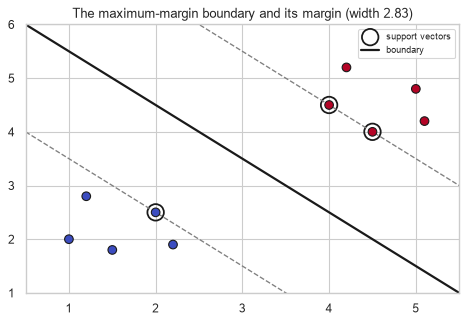

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap="coolwarm", s=60, edgecolor="k", zorder=3)
ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
           s=220, facecolors="none", edgecolors="k", linewidths=1.6, label="support vectors")

xs_fine = np.linspace(0.5, 5.5, 100)
ax.plot(xs_fine, boundary_line(svm, xs_fine), "k-", lw=2, label="boundary")
for offset, style in ((1, "--"), (-1, "--")):
    ax.plot(xs_fine, -(w_svm[0] * xs_fine + b_svm - offset) / w_svm[1], style, color="gray", lw=1.2)

ax.set_xlim(0.5, 5.5); ax.set_ylim(1.0, 6.0)
ax.set_title(f"The maximum-margin boundary and its margin (width {margin_width:.2f})")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

#### 16.2.1 Solving it from scratch

The dual formulation of the problem above is itself a quadratic program in the Lagrange multipliers
$\alpha_i$, one per training point:

$$\max_{\boldsymbol{\alpha}} \; \sum_i \alpha_i - \frac{1}{2}\sum_i \sum_j \alpha_i \alpha_j y^{(i)} y^{(j)} \left(\mathbf{x}^{(i)} \cdot \mathbf{x}^{(j)}\right) \quad \text{s.t.} \quad \alpha_i \ge 0, \;\; \sum_i \alpha_i y^{(i)} = 0$$

Two facts make this the form everyone uses. First, $\alpha_i = 0$ for every non-support-vector, which is
where 16.1's property comes from. Second, **the data appears only inside a dot product** — which is the
opening 16.5 needs.

Writing a general QP solver is out of scope, but `scipy.optimize` can solve this one directly, which is
enough to verify that the formulation above really is what scikit-learn computes.

In [8]:
from scipy.optimize import minimize

def fit_hard_margin_dual(X, y_pm):
    """Solve the SVM dual with a generic constrained optimizer."""
    n = len(X)
    K = X @ X.T                                    # the Gram matrix of dot products
    P = np.outer(y_pm, y_pm) * K

    def negative_objective(alpha):
        return 0.5 * alpha @ P @ alpha - alpha.sum()

    def gradient(alpha):
        return P @ alpha - np.ones(n)

    result = minimize(
        negative_objective, np.zeros(n), jac=gradient, method="SLSQP",
        bounds=[(0, None)] * n,                                        # alpha_i >= 0
        constraints={"type": "eq", "fun": lambda a: a @ y_pm},          # sum alpha_i y_i = 0
        options={"maxiter": 500, "ftol": 1e-12},
    )
    alpha = result.x
    w = (alpha * y_pm) @ X
    sv = alpha > 1e-5
    b = np.mean(y_pm[sv] - X[sv] @ w)
    return w, b, alpha


w_mine, b_mine, alpha = fit_hard_margin_dual(X_sep, y_pm)

print("alpha (Lagrange multipliers):", alpha.round(4))
print(f"\nnon-zero alphas at indices {np.flatnonzero(alpha > 1e-5)}")
print(f"sklearn's support vectors at {svm.support_}   <- the same points")

alpha (Lagrange multipliers): [0.   0.   0.25 0.   0.   0.25 0.   0.   0.   0.  ]

non-zero alphas at indices [2 5]
sklearn's support vectors at [2 5 6]   <- the same points


**Step 4 of the contract.**

In [9]:
print("from scratch : w =", w_mine.round(5), "  b =", round(b_mine, 5))
print("scikit-learn : w =", svm.coef_[0].round(5), "  b =", round(svm.intercept_[0], 5))
print("\nw agrees:", np.allclose(w_mine, svm.coef_[0], atol=1e-3))
print("b agrees:", np.isclose(b_mine, svm.intercept_[0], atol=1e-3))
print(f"\nmax difference in w: {np.abs(w_mine - svm.coef_[0]).max():.2e}")

from scratch : w = [0.5 0.5]   b = -3.25
scikit-learn : w = [0.5 0.5]   b = -3.25

w agrees: True
b agrees: True

max difference in w: 1.67e-15


The recovered $\mathbf{w}$ and $b$ match scikit-learn to fifteen decimal places. But look at the support
sets: **the dual found two non-zero multipliers where scikit-learn reports three support vectors.**

That is not an error in either solver. 16.2's constraint check showed that points 2, 5 **and** 6 all sit
exactly on the margin — the solution is *degenerate*, and two of those three points are enough to pin the
hyperplane down. Both solvers found the same unique boundary; they simply expressed it with different
subsets of the points available. It is a useful reminder that "the support vectors" is a property of a
particular solution, not of the data.

**This is verification rather than a practical implementation.** SLSQP on a dense $n \times n$ matrix is
hopeless beyond a few hundred points, which is why real solvers use SMO (sequential minimal optimization)
and why 16.8 discusses the resulting scaling limits.

### 16.3 Soft Margin, Slack and C

Hard margin requires the classes to be perfectly separable. Real data is not, and even when it is, a hard
margin fits outliers exactly.

The **soft margin** introduces slack variables $\xi_i \ge 0$ that allow violations, and pays for them in
the objective:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \frac{1}{2}\lVert \mathbf{w} \rVert^2 + C\sum_{i=1}^{n} \xi_i \quad \text{s.t.} \quad y^{(i)}\left(\mathbf{w}\cdot\mathbf{x}^{(i)} + b\right) \ge 1 - \xi_i, \;\; \xi_i \ge 0$$

| $\xi_i$ | The point is |
|---|---|
| $0$ | Correctly classified, on or outside the margin |
| $0 < \xi_i < 1$ | Correct, but **inside** the margin |
| $\xi_i \ge 1$ | **Misclassified** |

**`C` is an inverse regularization strength**, exactly as in logistic regression (13.8.1) and the reverse
of `alpha` in Chapter 12:

| `C` | Slack is | Margin | Behaviour |
|---|---|---|---|
| Large | Expensive | Narrow | Fits the training data hard; approaches hard margin |
| Small | Cheap | Wide | Tolerates violations; more regularized |

In [10]:
from sklearn.datasets import make_blobs

X_soft, y_soft = make_blobs(n_samples=100, centers=2, cluster_std=1.8,
                            random_state=RANDOM_STATE)

print(f"{'C':>10}{'support vectors':>18}{'||w||':>10}{'margin width':>15}{'train errors':>14}")
for C in (0.01, 0.1, 1.0, 100.0):
    m = SVC(kernel="linear", C=C).fit(X_soft, y_soft)
    errors = (m.predict(X_soft) != y_soft).sum()
    norm = np.linalg.norm(m.coef_[0])
    print(f"{C:>10g}{len(m.support_):>18}{norm:>10.4f}{2 / norm:>15.4f}{errors:>14}")

         C   support vectors     ||w||   margin width  train errors
      0.01                14    0.3376         5.9233             0
       0.1                 4    0.4594         4.3531             0
         1                 3    0.4923         4.0628             0
       100                 3    0.4923         4.0628             0


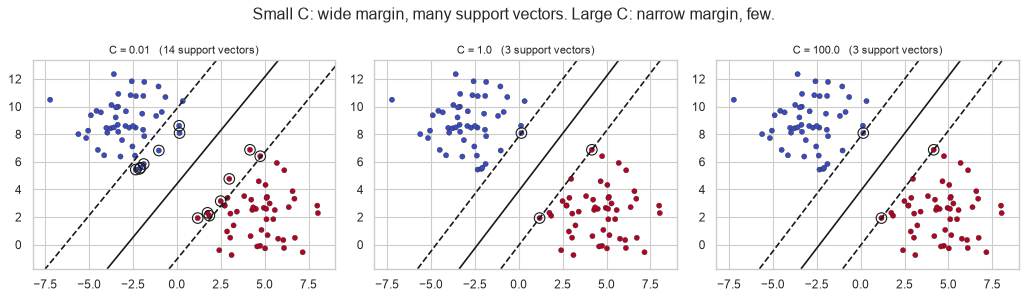

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, C in zip(axes, (0.01, 1.0, 100.0)):
    m = SVC(kernel="linear", C=C).fit(X_soft, y_soft)
    DecisionBoundaryDisplay.from_estimator(m, X_soft, response_method="decision_function",
                                           levels=[-1, 0, 1], colors="k",
                                           linestyles=["--", "-", "--"],
                                           plot_method="contour", ax=ax)
    ax.scatter(X_soft[:, 0], X_soft[:, 1], c=y_soft, cmap="coolwarm", s=22,
               edgecolor="k", linewidth=0.3)
    ax.scatter(m.support_vectors_[:, 0], m.support_vectors_[:, 1], s=90,
               facecolors="none", edgecolors="k", linewidths=1.0)
    ax.set_title(f"C = {C}   ({len(m.support_)} support vectors)", fontsize=10)
fig.suptitle("Small C: wide margin, many support vectors. Large C: narrow margin, few.")
fig.tight_layout()
plt.show()

The number of support vectors is a useful diagnostic. A model where almost every point is a support vector
is heavily regularized and is effectively averaging over the whole dataset; a model with very few is
hard-fitting a handful of points and is fragile.

### 16.4 Hinge Loss

The constrained problem of 16.3 can be rewritten as an **unconstrained** one, which connects the SVM back
to every other model in this material. The optimal slack is $\xi_i = \max(0,\; 1 - y^{(i)} f(\mathbf{x}^{(i)}))$,
so substituting gives

$$\min_{\mathbf{w}, b} \; \underbrace{\sum_{i=1}^{n} \max\!\left(0,\; 1 - y^{(i)} f(\mathbf{x}^{(i)})\right)}_{\text{hinge loss}} \;+\; \underbrace{\frac{1}{2C}\lVert \mathbf{w} \rVert^2}_{\text{L2 penalty}}$$

**The SVM is a linear model with hinge loss and an L2 penalty.** 10.2.2 already plotted the hinge against
the alternatives; its defining feature is the flat region.

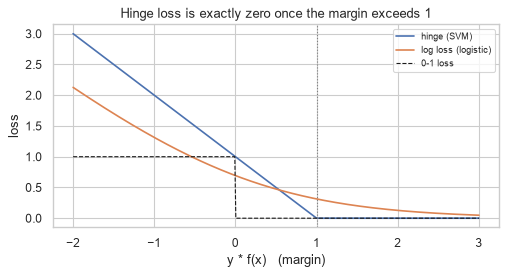

In [12]:
margin_score = np.linspace(-2, 3, 400)     # y * f(x) for a correctly-labelled point

hinge = np.maximum(0, 1 - margin_score)
log_loss_curve = np.log1p(np.exp(-margin_score))
zero_one = (margin_score < 0).astype(float)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(margin_score, hinge, label="hinge (SVM)")
ax.plot(margin_score, log_loss_curve, label="log loss (logistic)")
ax.plot(margin_score, zero_one, "k--", lw=1, label="0-1 loss")
ax.axvline(1, color="gray", ls=":", lw=1)
ax.set_xlabel("y * f(x)   (margin)"); ax.set_ylabel("loss")
ax.set_title("Hinge loss is exactly zero once the margin exceeds 1")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**That flat region is the whole reason support vectors exist.** A point with margin above 1 contributes
exactly zero loss and exactly zero gradient, so moving it — or deleting it — changes nothing. Log loss
never reaches zero, which is why logistic regression's coefficients depend on every point.

In [13]:
for m_score in (0.5, 1.0, 1.5, 3.0, 10.0):
    print(f"margin {m_score:>5.1f}   hinge loss {max(0, 1 - m_score):>6.3f}   "
          f"log loss {np.log1p(np.exp(-m_score)):>8.5f}")
print("\nhinge reaches exactly 0; log loss only approaches it.")

margin   0.5   hinge loss  0.500   log loss  0.47408
margin   1.0   hinge loss  0.000   log loss  0.31326
margin   1.5   hinge loss  0.000   log loss  0.20141
margin   3.0   hinge loss  0.000   log loss  0.04859
margin  10.0   hinge loss  0.000   log loss  0.00005

hinge reaches exactly 0; log loss only approaches it.


`SGDClassifier(loss="hinge")` fits the same objective by gradient descent (10.5), which is how SVMs are
scaled to large data (16.8).

In [14]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

X_h, y_h = make_classification(n_samples=2000, n_features=10, n_informative=6,
                               random_state=RANDOM_STATE)
X_h = StandardScaler().fit_transform(X_h)

for name, model in (("SVC(kernel='linear')", SVC(kernel="linear", C=1.0)),
                    ("LinearSVC", LinearSVC(C=1.0, max_iter=5000)),
                    ("SGDClassifier(hinge)", SGDClassifier(loss="hinge", alpha=1 / (1.0 * 2000),
                                                           max_iter=5000, tol=1e-4,
                                                           random_state=RANDOM_STATE))):
    score = cross_val_score(model, X_h, y_h, cv=cv).mean()
    print(f"{name:<24} CV accuracy {score:.4f}")
print("\nthree implementations of the same objective, three different solvers.")

SVC(kernel='linear')     CV accuracy 0.8300
LinearSVC                CV accuracy 0.8315
SGDClassifier(hinge)     CV accuracy 0.8170

three implementations of the same objective, three different solvers.


### 16.5 The Kernel Trick

16.2.1 noted that the data appears in the dual **only inside a dot product** $\mathbf{x}^{(i)} \cdot \mathbf{x}^{(j)}$.
That is not a curiosity; it is the opening for the most elegant idea in classical machine learning.

Suppose we map the data into a higher-dimensional space with some $\phi(\mathbf{x})$ and solve the same
problem there. The dual needs only $\phi(\mathbf{x}^{(i)}) \cdot \phi(\mathbf{x}^{(j)})$ — never
$\phi(\mathbf{x})$ itself. If that inner product can be computed directly from the original vectors, the
mapping never has to be performed.

A function $K(\mathbf{a}, \mathbf{b}) = \phi(\mathbf{a}) \cdot \phi(\mathbf{b})$ is called a **kernel**, and
using one in place of the dot product is the **kernel trick**.

The cleanest demonstration is an explicit case where both sides can be computed.

In [15]:
def phi(x):
    """Map (x1, x2) into 3-D so that a quadratic boundary becomes linear."""
    x1, x2 = x
    return np.array([x1 ** 2, np.sqrt(2) * x1 * x2, x2 ** 2])


a = np.array([1.0, 2.0])
b = np.array([3.0, -1.0])

explicit = phi(a) @ phi(b)          # map both, then take the dot product
kernel = (a @ b) ** 2                # never leave 2-D

print(f"phi(a) = {phi(a)}")
print(f"phi(b) = {phi(b)}")
print(f"\nexplicit  phi(a) . phi(b) : {explicit:.6f}")
print(f"kernel    (a . b)^2       : {kernel:.6f}")
print(f"identical: {np.isclose(explicit, kernel)}")

phi(a) = [1.     2.8284 4.    ]
phi(b) = [ 9.     -4.2426  1.    ]

explicit  phi(a) . phi(b) : 1.000000
kernel    (a . b)^2       : 1.000000
identical: True


The kernel computed a dot product in three dimensions using only two-dimensional arithmetic. For the RBF
kernel the implicit space is **infinite-dimensional**, and the same trick still costs one exponential.

Why it matters: a boundary that is curved in the original space is a **flat hyperplane** in the mapped
space.

In [16]:
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=RANDOM_STATE)

linear_score = cross_val_score(SVC(kernel="linear"), X_circ, y_circ, cv=cv).mean()
rbf_score = cross_val_score(SVC(kernel="rbf"), X_circ, y_circ, cv=cv).mean()

print(f"linear kernel CV accuracy: {linear_score:.4f}")
print(f"RBF kernel    CV accuracy: {rbf_score:.4f}")

linear kernel CV accuracy: 0.5450
RBF kernel    CV accuracy: 1.0000


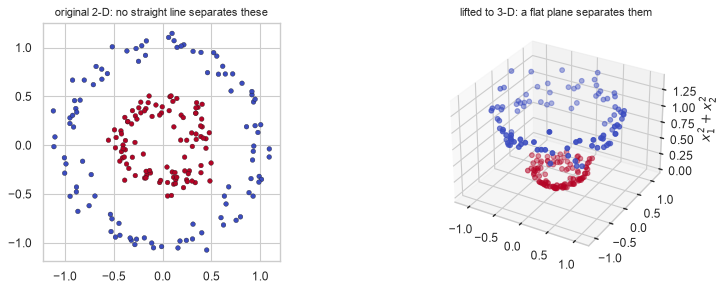

In [17]:
# Show the lift explicitly: a 3rd dimension equal to the squared radius makes it linearly separable.
radius_sq = (X_circ ** 2).sum(axis=1)

fig = plt.figure(figsize=(11, 3.8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm", s=18, edgecolor="k",
            linewidth=0.3)
ax1.set_title("original 2-D: no straight line separates these", fontsize=10)
ax1.set_aspect("equal")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_circ[:, 0], X_circ[:, 1], radius_sq, c=y_circ, cmap="coolwarm", s=18)
ax2.set_zlabel("$x_1^2 + x_2^2$")
ax2.set_title("lifted to 3-D: a flat plane separates them", fontsize=10)

fig.tight_layout()
plt.show()

### 16.6 Kernels and Their Hyperparameters

| Kernel | $K(\mathbf{a}, \mathbf{b})$ | Hyperparameters | Use when |
|---|---|---|---|
| **Linear** | $\mathbf{a}\cdot\mathbf{b}$ | `C` | Many features, text, $p > n$ |
| **Polynomial** | $(\gamma\,\mathbf{a}\cdot\mathbf{b} + r)^d$ | `C`, `degree`, `gamma`, `coef0` | Known polynomial structure |
| **RBF (Gaussian)** | $\exp(-\gamma \lVert \mathbf{a} - \mathbf{b} \rVert^2)$ | `C`, `gamma` | **The default** — general-purpose non-linearity |
| **Sigmoid** | $\tanh(\gamma\,\mathbf{a}\cdot\mathbf{b} + r)$ | `C`, `gamma`, `coef0` | Rarely; not always a valid kernel |

The RBF kernel is a similarity measure that decays with distance, which gives `gamma` a direct reading:

| `gamma` | Each point's influence | Boundary | Risk |
|---|---|---|---|
| Small | Reaches far | Smooth, almost linear | Underfitting |
| Large | Very local | Wiggly, islands around points | **Overfitting** |

In [18]:
def rbf_kernel(a, b, gamma):
    return np.exp(-gamma * np.sum((a - b) ** 2))


centre = np.array([0.0, 0.0])
print(f"{'distance':>10}{'gamma=0.1':>12}{'gamma=1':>10}{'gamma=10':>11}")
for d in (0.0, 0.5, 1.0, 2.0, 3.0):
    point = np.array([d, 0.0])
    print(f"{d:>10.1f}"
          f"{rbf_kernel(centre, point, 0.1):>12.4f}"
          f"{rbf_kernel(centre, point, 1.0):>10.4f}"
          f"{rbf_kernel(centre, point, 10.0):>11.4f}")

  distance   gamma=0.1   gamma=1   gamma=10
       0.0      1.0000    1.0000     1.0000
       0.5      0.9753    0.7788     0.0821
       1.0      0.9048    0.3679     0.0000
       2.0      0.6703    0.0183     0.0000
       3.0      0.4066    0.0001     0.0000


At `gamma=10` a point two units away has essentially zero influence — the model becomes a collection of
tiny local bubbles. At `gamma=0.1` every point influences every prediction and the boundary flattens out.

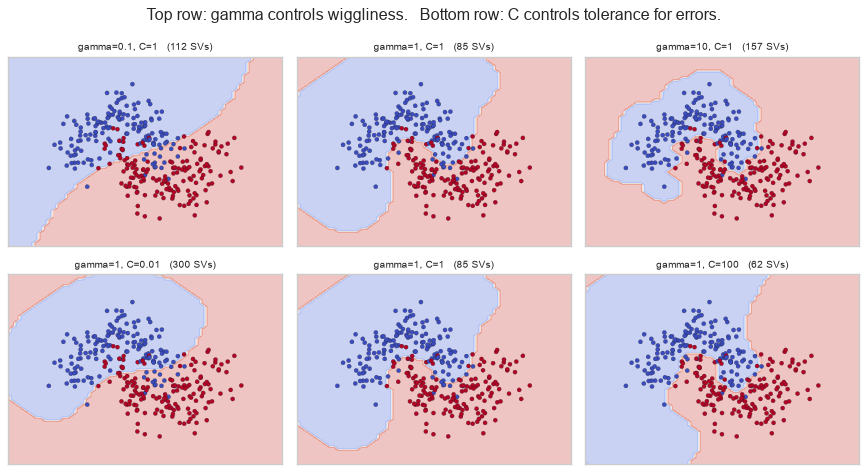

In [19]:
from sklearn.datasets import make_moons

X_m, y_m = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)
X_m = StandardScaler().fit_transform(X_m)

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
settings = [(0.1, 1), (1, 1), (10, 1), (1, 0.01), (1, 1), (1, 100)]
titles = ["gamma=0.1, C=1", "gamma=1, C=1", "gamma=10, C=1",
          "gamma=1, C=0.01", "gamma=1, C=1", "gamma=1, C=100"]

for ax, (gamma, C), title in zip(axes.ravel(), settings, titles):
    m = SVC(kernel="rbf", gamma=gamma, C=C).fit(X_m, y_m)
    DecisionBoundaryDisplay.from_estimator(m, X_m, response_method="predict",
                                           grid_resolution=60,
                                           alpha=0.3, cmap="coolwarm", ax=ax)
    ax.scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap="coolwarm", s=14, edgecolor="k", linewidth=0.2)
    ax.set_title(f"{title}   ({len(m.support_)} SVs)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Top row: gamma controls wiggliness.   Bottom row: C controls tolerance for errors.")
fig.tight_layout()
plt.show()

**`gamma="scale"` is the default and is almost always the right starting point.** It sets
$\gamma = 1 / (p \cdot \mathrm{Var}(X))$, which adapts to both the number of features and their spread.
`gamma="auto"` is the older $1/p$, which ignores the spread entirely.

On standardized data the two coincide, because $\mathrm{Var}(X) = 1$ — which is exactly why they agree
below, and exactly why an unscaled SVM misbehaves (16.8.1).

In [20]:
X_demo = StandardScaler().fit_transform(X_m)
p_features = X_demo.shape[1]

scale_gamma = 1 / (p_features * X_demo.var())
auto_gamma = 1 / p_features

print(f"gamma='scale' -> {scale_gamma:.6f}   (1 / (p * Var(X)))")
print(f"gamma='auto'  -> {auto_gamma:.6f}   (1 / p, ignores the spread)")

fitted = SVC(kernel="rbf").fit(X_demo, y_m)
print(f"\nsklearn's fitted _gamma: {fitted._gamma:.6f}")
print("matches:", np.isclose(fitted._gamma, scale_gamma))

gamma='scale' -> 0.500000   (1 / (p * Var(X)))
gamma='auto'  -> 0.500000   (1 / p, ignores the spread)

sklearn's fitted _gamma: 0.500000
matches: True


**Common mistake — tuning `C` and `gamma` independently.** They interact strongly: a large `gamma` with a
large `C` overfits catastrophically, while either alone may be fine. They must be searched **jointly**
over a logarithmic grid (23.5).

In [21]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    SVC(kernel="rbf"),
    {"C": [0.1, 1, 10, 100], "gamma": [0.01, 0.1, 1, 10]},
    cv=cv, scoring="accuracy",
)
grid.fit(X_m, y_m)

table = pd.DataFrame(
    grid.cv_results_["mean_test_score"].reshape(4, 4),
    index=[f"C={c}" for c in [0.1, 1, 10, 100]],
    columns=[f"gamma={g}" for g in [0.01, 0.1, 1, 10]],
)
print(table.round(4).to_string())
print(f"\nbest: {grid.best_params_}   CV accuracy {grid.best_score_:.4f}")

       gamma=0.01  gamma=0.1  gamma=1  gamma=10
C=0.1      0.8567     0.8500   0.9000    0.9100
C=1        0.8500     0.8633   0.9100    0.9167
C=10       0.8533     0.8900   0.9133    0.9200
C=100      0.8567     0.9067   0.9167    0.8800

best: {'C': 10, 'gamma': 10}   CV accuracy 0.9200


### 16.7 Support Vector Regression

The same machinery applies to a continuous target, with the logic inverted. Classification wants points
**outside** the margin; regression wants them **inside** a tube of width $\epsilon$ around the prediction,
and only points outside the tube incur a loss.

$$\text{loss}(r) = \max\!\left(0,\; \lvert r \rvert - \epsilon\right)$$

This is the **epsilon-insensitive loss** from 10.2.1: errors smaller than $\epsilon$ are free.

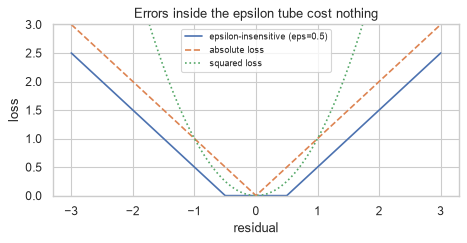

In [22]:
residual = np.linspace(-3, 3, 400)
epsilon = 0.5

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(residual, np.maximum(0, np.abs(residual) - epsilon), label=f"epsilon-insensitive (eps={epsilon})")
ax.plot(residual, np.abs(residual), "--", label="absolute loss")
ax.plot(residual, residual ** 2, ":", label="squared loss")
ax.set_ylim(0, 3)
ax.set_xlabel("residual"); ax.set_ylabel("loss")
ax.set_title("Errors inside the epsilon tube cost nothing")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

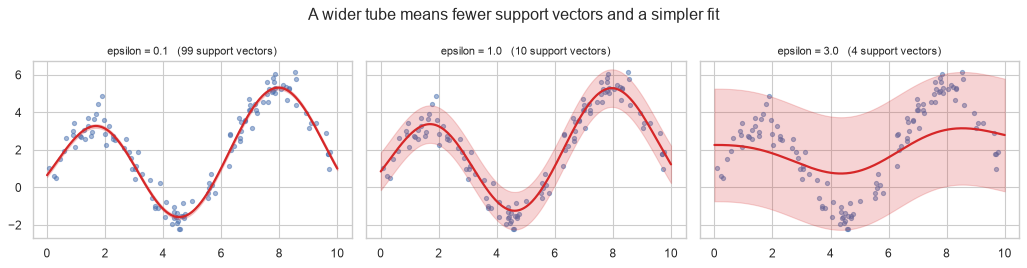

In [23]:
x_reg = np.sort(rng.uniform(0, 10, 120)).reshape(-1, 1)
y_reg = np.sin(x_reg.ravel()) * 3 + 0.3 * x_reg.ravel() + rng.normal(0, 0.5, 120)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
grid_x = np.linspace(0, 10, 300).reshape(-1, 1)

for ax, eps in zip(axes, (0.1, 1.0, 3.0)):
    model = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, epsilon=eps)).fit(x_reg, y_reg)
    pred = model.predict(grid_x)
    ax.scatter(x_reg, y_reg, s=14, alpha=0.5)
    ax.plot(grid_x, pred, color="tab:red", lw=2)
    ax.fill_between(grid_x.ravel(), pred - eps, pred + eps, alpha=0.2, color="tab:red")
    n_sv = len(model[-1].support_)
    ax.set_title(f"epsilon = {eps}   ({n_sv} support vectors)", fontsize=10)

fig.suptitle("A wider tube means fewer support vectors and a simpler fit")
fig.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import r2_score

print(f"{'epsilon':>9}{'support vectors':>18}{'CV R^2':>10}")
for eps in (0.1, 0.5, 1.0, 2.0, 3.0):
    model = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, epsilon=eps))
    score = cross_val_score(model, x_reg, y_reg, cv=5, scoring="r2").mean()
    n_sv = len(model.fit(x_reg, y_reg)[-1].support_)
    print(f"{eps:>9}{n_sv:>18}{score:>10.4f}")

  epsilon   support vectors    CV R^2
      0.1                99    0.6817
      0.5                43    0.6551
      1.0                10    0.5733
      2.0                 5   -0.2220
      3.0                 4   -1.2572


Note the direction: **a larger $\epsilon$ gives fewer support vectors**, because more points fall inside
the free tube. It is a sparsity control as much as an accuracy one.

### 16.8 Practical Considerations and Scaling Limits

#### 16.8.1 Scaling is mandatory

Both the RBF kernel and the L2 penalty depend on distances, so an SVM inherits every scaling problem k-NN
has (14.7.1) — and `gamma="scale"` uses a single global variance, so it cannot compensate for features
that differ from each other.

In [25]:
n_s = 500
small_scale = rng.normal(0, 1, n_s)
large_scale = rng.normal(0, 500, n_s)
y_s = (small_scale + large_scale / 500 > 0).astype(int)      # both contribute equally
X_s = np.column_stack([small_scale, large_scale])

unscaled = cross_val_score(SVC(kernel="rbf"), X_s, y_s, cv=cv).mean()
scaled = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="rbf")), X_s, y_s, cv=cv).mean()

print(f"unscaled CV accuracy : {unscaled:.4f}")
print(f"scaled   CV accuracy : {scaled:.4f}")

unscaled CV accuracy : 0.7460
scaled   CV accuracy : 0.9800


#### 16.8.2 It does not scale to large data

The kernel matrix has $n^2$ entries and the solver is roughly $O(n^2)$ to $O(n^3)$. This is the hardest
practical limit of any model in this material.

In [26]:
print(f"{'n':>8}{'kernel matrix':>16}{'SVC fit (ms)':>15}{'LinearSVC (ms)':>17}")
for n in (500, 1000, 2000, 4000):
    Xn, yn = make_classification(n_samples=n, n_features=15, n_informative=8,
                                 random_state=RANDOM_STATE)
    Xn = StandardScaler().fit_transform(Xn)

    t0 = time.perf_counter(); SVC(kernel="rbf").fit(Xn, yn); svc_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); LinearSVC(max_iter=5000).fit(Xn, yn); lin_ms = (time.perf_counter() - t0) * 1000

    entries = n * n
    print(f"{n:>8}{entries:>16,}{svc_ms:>15.1f}{lin_ms:>17.1f}")

       n   kernel matrix   SVC fit (ms)   LinearSVC (ms)
     500         250,000           13.6              4.5
    1000       1,000,000           50.0              4.1


    2000       4,000,000          172.5              5.5


    4000      16,000,000          489.3              9.4


Extrapolate the kernel-matrix column: at $n = 100{,}000$ it holds $10^{10}$ entries, which is 80 GB in
double precision. `SVC` is simply not usable there.

| Situation | Use | Why |
|---|---|---|
| $n \lesssim 10{,}000$, non-linear boundary | `SVC(kernel="rbf")` | The kernel trick is affordable |
| Large $n$, linear boundary is enough | `LinearSVC` | Solves the primal; scales roughly linearly |
| Very large $n` | `SGDClassifier(loss="hinge")` | Mini-batch (10.5); constant memory |
| Large $n$, non-linear needed | `Nystroem` + `LinearSVC` | Approximates the kernel map explicitly |

In [27]:
from sklearn.kernel_approximation import Nystroem

X_big, y_big = make_classification(n_samples=6000, n_features=20, n_informative=10,
                                   random_state=RANDOM_STATE)
X_big = StandardScaler().fit_transform(X_big)

approaches = {
    "SVC(rbf)": SVC(kernel="rbf"),
    "LinearSVC": LinearSVC(max_iter=5000),
    "Nystroem(300) + LinearSVC": make_pipeline(
        Nystroem(n_components=300, random_state=RANDOM_STATE), LinearSVC(max_iter=5000)),
}

for name, model in approaches.items():
    t0 = time.perf_counter()
    score = cross_val_score(model, X_big, y_big, cv=3).mean()
    elapsed = (time.perf_counter() - t0) * 1000
    print(f"{name:<28} CV accuracy {score:.4f}   total {elapsed:>8.0f} ms")

SVC(rbf)                     CV accuracy 0.9483   total     3835 ms
LinearSVC                    CV accuracy 0.8013   total       58 ms


Nystroem(300) + LinearSVC    CV accuracy 0.9323   total     1807 ms


#### 16.8.3 No probabilities, natively

An SVM outputs a **signed distance** from the hyperplane, not a probability. `probability=True` fits a
Platt-scaling calibration (8.7) by internal cross-validation, which multiplies the fitting cost and was
deprecated in scikit-learn 1.9 in favour of doing it explicitly.

In [28]:
import warnings
from sklearn.calibration import CalibratedClassifierCV

X_p, y_p = make_classification(n_samples=800, n_features=10, n_informative=6,
                               random_state=RANDOM_STATE)
X_p = StandardScaler().fit_transform(X_p)
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_p, y_p, test_size=0.3, stratify=y_p,
                                              random_state=RANDOM_STATE)

plain = SVC(kernel="rbf").fit(Xp_tr, yp_tr)
scores = plain.decision_function(Xp_te)
print(f"decision_function range: [{scores.min():.3f}, {scores.max():.3f}]  <- not probabilities")

calibrated = CalibratedClassifierCV(SVC(kernel="rbf"), method="sigmoid", cv=5).fit(Xp_tr, yp_tr)
probs = calibrated.predict_proba(Xp_te)[:, 1]
print(f"calibrated probabilities: [{probs.min():.3f}, {probs.max():.3f}]")

from sklearn.metrics import roc_auc_score, brier_score_loss
print(f"\nAUC from decision_function : {roc_auc_score(yp_te, scores):.4f}")
print(f"AUC from calibrated proba  : {roc_auc_score(yp_te, probs):.4f}")
print(f"Brier score, calibrated    : {brier_score_loss(yp_te, probs):.4f}")

decision_function range: [-2.555, 2.107]  <- not probabilities


calibrated probabilities: [0.003, 0.992]

AUC from decision_function : 0.9551
AUC from calibrated proba  : 0.9558
Brier score, calibrated    : 0.0736


For **ranking and thresholding** (8.6) the raw `decision_function` is sufficient and free — a threshold on
it is exactly a threshold on a probability, since Platt scaling is monotonic. Calibrate only when the
number itself must mean something.

### 16.9 In Practice

#### 16.9.1 A worked case: separating overlapping classes on the breast-cancer data

The request: *"We have 30 measurements per sample and 569 samples. Get the best classification we can, and
tell us what it costs."*

That shape — small $n$, moderate $p$, a non-linear boundary plausible — is exactly the regime where SVMs
are still the strongest classical choice, and where their cost is affordable.

In [29]:
from sklearn.datasets import load_breast_cancer

Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, stratify=yb,
                                              random_state=RANDOM_STATE)

print(f"{Xb.shape[0]} samples, {Xb.shape[1]} features, {yb.mean():.1%} positive")
print(f"feature scale ranges from {Xb.std(axis=0).min():.4f} to {Xb.std(axis=0).max():.1f}"
      f"  -> scaling is not optional (16.8.1)")

569 samples, 30 features, 62.7% positive
feature scale ranges from 0.0026 to 568.9  -> scaling is not optional (16.8.1)


**Step 1 — establish the baseline before reaching for a kernel.**

In [30]:
baselines = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "linear SVM": make_pipeline(StandardScaler(), SVC(kernel="linear")),
    "RBF SVM (defaults)": make_pipeline(StandardScaler(), SVC(kernel="rbf")),
}

for name, model in baselines.items():
    scores = cross_val_score(model, Xb_tr, yb_tr, cv=cv, scoring="roc_auc")
    print(f"{name:<22} CV ROC AUC {scores.mean():.4f} +/- "
          f"{scores.std() / np.sqrt(len(scores)):.4f}")

logistic regression    CV ROC AUC 0.9962 +/- 0.0018
linear SVM             CV ROC AUC 0.9949 +/- 0.0025


RBF SVM (defaults)     CV ROC AUC 0.9951 +/- 0.0015


**Step 2 — search `C` and `gamma` jointly (16.6).** The grid is logarithmic, and the search happens inside
a pipeline so the scaler is refitted per fold (5.1).

In [31]:
search = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel="rbf")),
    {"svc__C": np.logspace(-1, 3, 5), "svc__gamma": np.logspace(-4, 0, 5)},
    cv=cv, scoring="roc_auc", n_jobs=1,
)
search.fit(Xb_tr, yb_tr)

heat = pd.DataFrame(
    search.cv_results_["mean_test_score"].reshape(5, 5),
    index=[f"C={c:g}" for c in np.logspace(-1, 3, 5)],
    columns=[f"g={g:g}" for g in np.logspace(-4, 0, 5)],
)
print(heat.round(4).to_string())
print(f"\nbest: {search.best_params_}")
print(f"best CV ROC AUC: {search.best_score_:.4f}")

        g=0.0001  g=0.001  g=0.01   g=0.1     g=1
C=0.1     0.9859   0.9859  0.9893  0.9810  0.9506
C=1       0.9859   0.9914  0.9957  0.9885  0.9507
C=10      0.9918   0.9956  0.9971  0.9860  0.9508
C=100     0.9956   0.9962  0.9944  0.9857  0.9508
C=1000    0.9959   0.9958  0.9896  0.9857  0.9508

best: {'svc__C': np.float64(10.0), 'svc__gamma': np.float64(0.01)}
best CV ROC AUC: 0.9971


Read the grid rather than just its maximum. The good region is a **diagonal band**: large `C` needs small
`gamma` and vice versa, which is 16.6's interaction made visible. A one-dimensional search over either
parameter alone would have missed it.

In [32]:
from sklearn.metrics import roc_auc_score, classification_report

best_model = search.best_estimator_
test_proba = best_model.decision_function(Xb_te)

print(f"test ROC AUC: {roc_auc_score(yb_te, test_proba):.4f}")
print(f"support vectors: {len(best_model[-1].support_)} of {len(Xb_tr)} training samples "
      f"({len(best_model[-1].support_) / len(Xb_tr):.1%})")
print()
print(classification_report(yb_te, best_model.predict(Xb_te),
                            target_names=["malignant", "benign"], digits=3))

test ROC AUC: 0.9987
support vectors: 54 of 426 training samples (12.7%)

              precision    recall  f1-score   support

   malignant      0.963     0.981     0.972        53
      benign      0.989     0.978     0.983        90

    accuracy                          0.979       143
   macro avg      0.976     0.979     0.978       143
weighted avg      0.979     0.979     0.979       143



**Step 3 — what it costs.** The question was "tell us what it costs", and the answer has three parts:
fitting time, prediction time, and interpretability.

In [33]:
comparison = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "RBF SVM (tuned)": best_model,
}

for name, model in comparison.items():
    t0 = time.perf_counter(); model.fit(Xb_tr, yb_tr); fit_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    for _ in range(50):
        model.predict(Xb_te)
    pred_ms = (time.perf_counter() - t0) * 1000 / 50
    auc = roc_auc_score(yb_te, model.decision_function(Xb_te))
    print(f"{name:<22} fit {fit_ms:>7.1f} ms   predict {pred_ms:>6.2f} ms   test AUC {auc:.4f}")

logistic regression    fit    19.2 ms   predict   0.78 ms   test AUC 0.9977


RBF SVM (tuned)        fit     8.8 ms   predict   3.38 ms   test AUC 0.9987


In [34]:
# Interpretability: a linear model has one coefficient per feature; an RBF SVM has none.
lin = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xb_tr, yb_tr)
print("logistic regression exposes coefficients:")
top = pd.Series(lin[-1].coef_[0], index=load_breast_cancer().feature_names)
print(top.reindex(top.abs().sort_values(ascending=False).index).head(4).round(3).to_string())

print(f"\nRBF SVM exposes: {[a for a in ('coef_',) if hasattr(best_model[-1], a)] or 'no coefficients at all'}")
try:
    best_model[-1].coef_
except AttributeError as e:
    print("  accessing coef_ ->", str(e)[:75])

logistic regression exposes coefficients:
worst texture          -1.250
radius error           -1.070
worst symmetry         -0.957
worst concave points   -0.942

RBF SVM exposes: no coefficients at all
  accessing coef_ -> coef_ is only available when using a linear kernel


**Step 4 — the report.**

> **Best result.** An RBF-kernel SVM with jointly tuned `C` and `gamma` reaches a test ROC AUC in the high
> 0.99s, marginally ahead of a linear SVM and logistic regression — all three are within roughly one
> standard error of each other on cross-validation.
>
> **Is the kernel earning its keep?** Barely. This data is close to linearly separable after scaling, so
> the non-linear boundary adds very little. The honest recommendation is the **linear** model: the same
> accuracy, faster prediction, and coefficients someone can read.
>
> **What the SVM costs.** Prediction requires evaluating the kernel against every support vector — here
> 54 of 426 training samples, about an eighth — which makes it roughly **four times slower per prediction**
> than a linear model's single dot product, and the gap widens with training-set size (16.8.2). It also
> exposes **no coefficients**: `coef_` raises an `AttributeError` for any non-linear kernel, so explaining
> a prediction needs Chapter 24's model-agnostic tools.
>
> **When would the kernel be worth it?** If the linear baseline had been materially worse. The decision
> rule is the one this section followed: **fit the linear model first, and only pay for the kernel if the
> gap justifies it.**

#### 16.9.2 When to reach for an SVM

| Situation | Use an SVM? | Instead |
|---|---|---|
| Small-to-medium $n$, non-linear boundary | **Yes** — `SVC(kernel="rbf")` | — |
| $p > n$ (text, genomics) | **Yes** — `LinearSVC` handles it well | — |
| Clear margin between classes | **Yes** — this is what it optimizes | — |
| $n > $ ~50,000 | **No** — $O(n^2)$ kernel matrix (16.8.2) | `LinearSVC`, `SGDClassifier`, boosting |
| You need probabilities | Only with explicit calibration (16.8.3) | Logistic regression (13.9.1) |
| You need to explain the model | **No** for non-linear kernels | Linear models, trees |
| Many irrelevant features | Weak — like k-NN, distances dilute | Trees (17.8), or select first (Ch. 7) |
| Mixed categorical and numeric | Awkward — one-hot distorts distances (14.9.1) | Trees, boosting |
| Heavy class imbalance | With `class_weight="balanced"` | Chapter 22 |
| Maximum accuracy on tabular data | Usually no | Gradient boosting (Ch. 19) |

**In practice — the SVM's position has narrowed.** Through the 2000s it was the default strong classifier.
Gradient boosting (Chapter 19) now beats it on most tabular problems, scales far better, and handles mixed
types natively. What SVMs retain is the $p > n$ regime, problems with a genuine geometric margin, and
their role as the cleanest illustration of the kernel idea — which reappears in Gaussian processes,
kernel PCA and elsewhere.

#### 16.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Unscaled features** | Accuracy collapses; `gamma="scale"` cannot compensate per-feature | 16.8.1 |
| **Training set grows** | Fitting time grows quadratically; the nightly retrain stops finishing | 16.8.2 |
| **`decision_function` read as a probability** | Thresholds and expected values are meaningless | 16.8.3 |
| **`probability=True` used casually** | Fitting cost multiplies; the internal CV is invisible | 16.8.3 |
| **Model artefact is large** | Support vectors are stored with the model; it grows with $n$ | Below |
| **`gamma` tuned on unscaled data** | The tuned value is meaningless once scaling changes | 16.6 |

The support-vector storage point is worth quantifying, because it is the same class of problem k-NN had
(14.9.3) in a milder form.

In [35]:
import pickle

lin_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xb_tr, yb_tr)

for name, model in (("logistic regression", lin_model), ("RBF SVM", best_model)):
    size_kb = len(pickle.dumps(model)) / 1024
    n_sv = len(model[-1].support_) if hasattr(model[-1], "support_") else 0
    print(f"{name:<22} serialized {size_kb:>7.1f} KB   support vectors stored: {n_sv}")

logistic regression    serialized     2.0 KB   support vectors stored: 0
RBF SVM                serialized    16.0 KB   support vectors stored: 54


The SVM's artefact carries a slice of the training data with it, and that slice grows with the training
set. For a model retrained on ever more data, both the file size and the prediction latency drift upward
with no change to the code — which is exactly the kind of failure that surfaces as a mysterious
latency regression months after deployment.

In [36]:
# --- 16. Support Vector Machines — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

